<a href="https://colab.research.google.com/github/Sarah-0405/Cold_Spots_Bayern/blob/main/LCZs_Cold_Spots_Kombination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
lcz_path = "/content/drive/MyDrive/Cold Spots Bayern/LCZs_bayern.tif"

Daten heruntergeladen von https://figshare.com/articles/dataset/European_LCZ_map/13322450 / WUDAPT und dann auf bayern zugeschnitten (QGIS)

In [3]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 75.7 MB/s eta 0:00:00


# Städte extrahieren


nochmal mit Stadtpolygonen verknüpfen und mit genauen Koordinaten berechnen

In [5]:
import geopandas as gpd

# Define the path to the GeoPackage file
city_boundaries_path = "/content/drive/MyDrive/Cold Spots Bayern/grenzen_ueber_50tsd.gpkg"

# Load the GeoPackage file into a GeoDataFrame
city_boundaries_gdf = gpd.read_file(city_boundaries_path)

# Display the first few rows and the CRS of the GeoDataFrame
print("City Boundaries GeoDataFrame:")
display(city_boundaries_gdf.head())
print("\nCity Boundaries CRS:")
print(city_boundaries_gdf.crs)

City Boundaries GeoDataFrame:


,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,geometry
0,11.360777,48.061624,11.722910,48.248116,116687199,relation,62428,48.137108,11.575382,boundary,administrative,12,0.799006,city,Munich,"Munich, Bavaria, Germany","MULTIPOLYGON (((11.36078 48.15807, 11.36085 48..."
1,10.988733,49.331434,11.282596,49.540753,115962439,relation,62780,49.453872,11.077298,boundary,administrative,12,0.709195,city,Nuremberg,"Nuremberg, Bavaria, Germany","MULTIPOLYGON (((10.98873 49.53654, 10.98906 49..."
2,10.763362,48.258144,10.959333,48.458654,116219980,relation,62407,48.369034,10.897952,boundary,administrative,12,0.679385,city,Augsburg,"Augsburg, Bavaria, Germany","MULTIPOLYGON (((10.76336 48.30213, 10.76336 48..."
3,12.029075,48.966746,12.191608,49.076416,119951011,relation,62411,49.019533,12.097487,boundary,administrative,12,0.670191,city,Regensburg,"Regensburg, Bavaria, Germany","MULTIPOLYGON (((12.02907 49.01102, 12.02908 49..."
4,11.255908,48.683877,11.503422,48.822891,116627625,relation,62381,48.763016,11.425040,boundary,administrative,12,0.625744,city,Ingolstadt,"Ingolstadt, Bavaria, Germany","MULTIPOLYGON (((11.25591 48.77946, 11.25634 48..."



City Boundaries CRS:
EPSG:4326


In [10]:
import geopandas as gpd
from shapely.geometry import MultiPolygon # Import MultiPolygon if needed

# Step 1: Use the loaded city_boundaries_gdf
# Extract city names and geometries from the GeoDataFrame and retain CRS
cities_to_extract_gdf = {}
# Get the CRS from the original GeoDataFrame
source_crs = city_boundaries_gdf.crs

for index, row in city_boundaries_gdf.iterrows():
    city_name = row['name']
    geometry = row['geometry']

    # Create a GeoSeries for the individual geometry with the source CRS
    # This ensures the geometry object is associated with the CRS
    if source_crs is not None:
        geo_series = gpd.GeoSeries([geometry], crs=source_crs)
        geometry_with_crs = geo_series.iloc[0]
    else:
        geometry_with_crs = geometry # Use geometry without CRS if source_crs is None


    cities_to_extract_gdf[city_name] = geometry_with_crs


# Step 2 & 3: Store the information (already done in the dictionary)
print("Cities to extract and their geometries from city_boundaries_gdf:")
for city, geometry in cities_to_extract_gdf.items():
    # Print a simplified representation of the geometry and its CRS
    print(f"- {city}: {geometry.geom_type}, CRS: {geometry.crs}")

Cities to extract and their geometries from city_boundaries_gdf:


AttributeError: 'MultiPolygon' object has no attribute 'crs'

## Raster zuschneiden (Clipping)

In [11]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
import geopandas as gpd
from rasterio.warp import transform
import numpy as np # Import numpy for np.all

# Open the raster file
with rasterio.open(lcz_path) as src:
    # Get the raster's coordinate reference system (CRS)
    raster_crs = src.crs

    clipped_rasters = {}

    # Define the input CRS of the city boundary geometries (from city_boundaries_gdf)
    input_crs = city_boundaries_gdf.crs # Use the CRS directly from the source GeoDataFrame

    if input_crs is None:
        print("Warning: Input city boundaries GeoDataFrame does not have a defined CRS.")
        # You might need to set a default input_crs here if it's expected to be known
        # For now, we'll proceed, but transformation might fail if CRS is needed.

    for city, geometry in cities_to_extract_gdf.items():
        try:
            # Create a GeoSeries for the current geometry with the input CRS
            # This is the correct way to associate a CRS with a shapely geometry for transformation
            if input_crs is not None:
                geo_series = gpd.GeoSeries([geometry], crs=input_crs)
            else:
                # If input_crs is None, create GeoSeries without CRS - transformation below will likely fail if needed
                geo_series = gpd.GeoSeries([geometry])


            # Ensure the city geometry is in the raster's CRS for accurate clipping
            # Transform the GeoSeries to the raster's CRS
            if geo_series.crs != raster_crs:
                 print(f"Transforming geometry for {city} from {geo_series.crs} to {raster_crs}")
                 transformed_geometry = geo_series.to_crs(raster_crs).iloc[0]
            else:
                # If the geometry's CRS already matches the raster's CRS (unlikely given the source)
                transformed_geometry = geo_series.iloc[0]
                print(f"Geometry for {city} already in raster CRS ({raster_crs}).")


            # Use the transformed geometry directly for masking
            # mask expects a list of geometries
            geoms = [transformed_geometry]

            # Clip the raster using the transformed city boundary geometry
            # Setting crop=True will crop the output raster to the extent of the clipping geometry
            clipped_data, clipped_transform = mask(src, geoms, crop=True)

            # Store the clipped data and its transform if the clipped data is not empty
            # Check if clipped_data is not None and has data
            if clipped_data is not None and clipped_data.size > 0 and not np.all(clipped_data == src.nodata): # Also check if not all nodata
                 clipped_rasters[city] = {
                    "data": clipped_data,
                    "transform": clipped_transform,
                    "crs": src.crs,
                    "meta": src.meta.copy() # Copy metadata
                }
                # Update metadata for the clipped raster
                 clipped_rasters[city]["meta"].update({
                    "height": clipped_data.shape[1],
                    "width": clipped_data.shape[2],
                    "transform": clipped_transform
                })
                 print(f"Successfully clipped raster for {city}.")
            else:
                print(f"Clipped data for {city} is empty or all NoData. Geometry might be outside raster extent or cover only NoData areas.")
                clipped_rasters[city] = None # Indicate clipping resulted in empty or nodata data


        except Exception as e:
            print(f"Could not clip raster for {city} due to an error: {e}")
            clipped_rasters[city] = None # Indicate clipping failed for this city


# Now clipped_rasters dictionary contains the clipped data for each city (or None if failed)
print("\nClipped rasters created (or attempted) for the specified cities.")

# Filter out cities where clipping failed
successfully_clipped_cities = {city: data for city, data in clipped_rasters.items() if data is not None}

if not successfully_clipped_cities:
    print("\nNo rasters were successfully clipped.")
else:
    print(f"\nSuccessfully clipped rasters for the following cities: {list(successfully_clipped_cities.keys())}")

Transforming geometry for Munich from EPSG:4326 to EPSG:3035
Successfully clipped raster for Munich.
Transforming geometry for Nuremberg from EPSG:4326 to EPSG:3035
Successfully clipped raster for Nuremberg.
Transforming geometry for Augsburg from EPSG:4326 to EPSG:3035
Successfully clipped raster for Augsburg.
Transforming geometry for Regensburg from EPSG:4326 to EPSG:3035
Successfully clipped raster for Regensburg.
Transforming geometry for Ingolstadt from EPSG:4326 to EPSG:3035
Successfully clipped raster for Ingolstadt.
Transforming geometry for Würzburg from EPSG:4326 to EPSG:3035
Successfully clipped raster for Würzburg.
Transforming geometry for Fürth from EPSG:4326 to EPSG:3035
Successfully clipped raster for Fürth.
Transforming geometry for Erlangen from EPSG:4326 to EPSG:3035
Successfully clipped raster for Erlangen.
Transforming geometry for Bamberg from EPSG:4326 to EPSG:3035
Successfully clipped raster for Bamberg.
Transforming geometry for Bayreuth from EPSG:4326 to EPSG

## Visualisierung

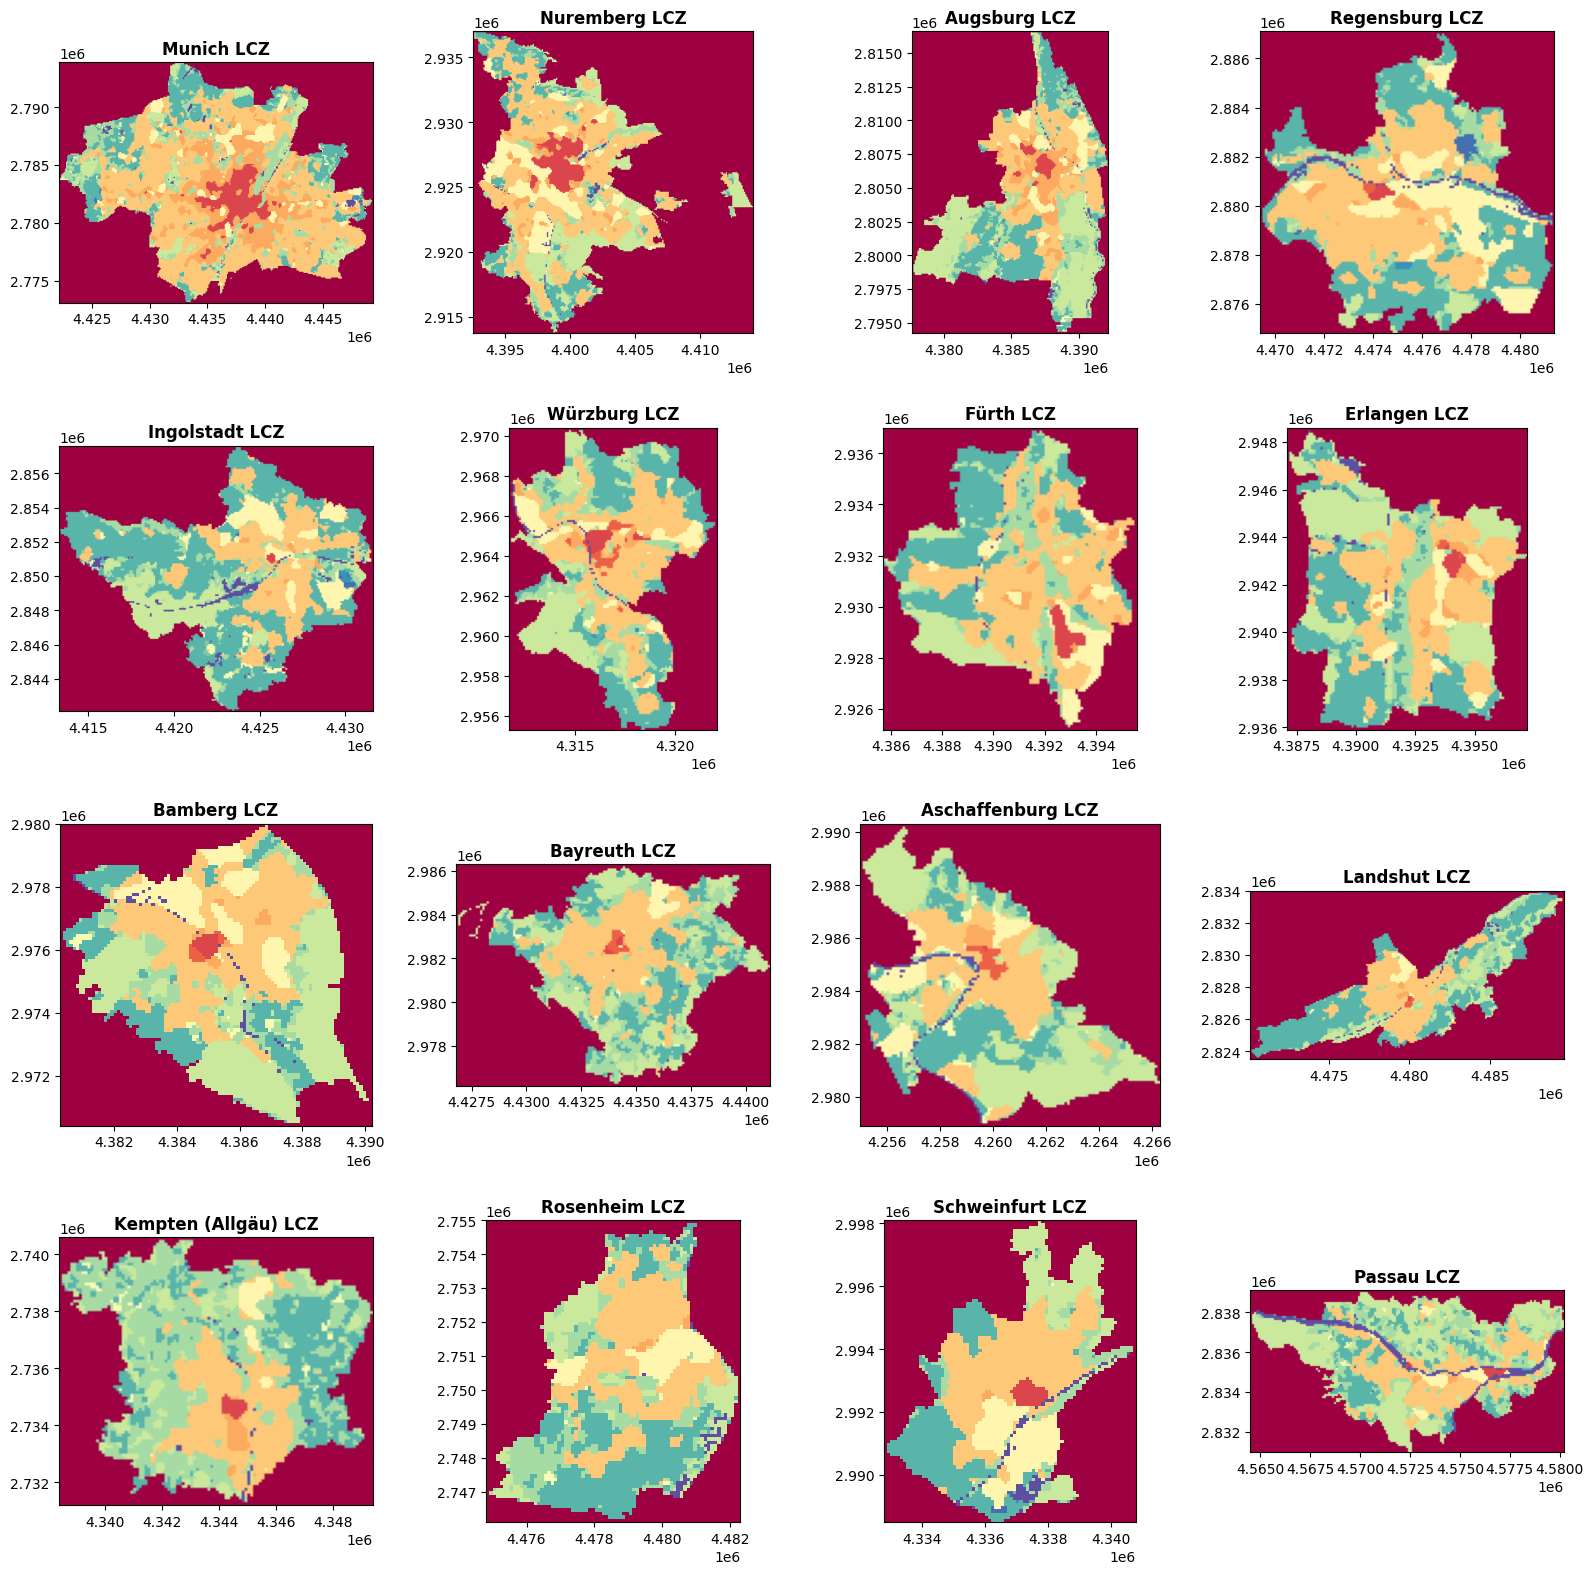

In [12]:
import matplotlib.pyplot as plt
from rasterio.plot import show

# Filter out cities where clipping was not successful
cities_to_visualize = {city: data for city, data in clipped_rasters.items() if data is not None}

if not cities_to_visualize:
    print("No cities were successfully clipped, so no visualizations can be displayed.")
else:
    # Determine the number of cities and calculate grid dimensions for subplots
    num_cities = len(cities_to_visualize)
    cols = 4  # Number of columns for the grid
    rows = (num_cities + cols - 1) // cols # Calculate rows needed

    # Create a figure and a set of subplots
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Iterate through the successfully clipped rasters and plot each one
    for i, (city, clipped_info) in enumerate(cities_to_visualize.items()):
        clipped_data = clipped_info["data"]
        clipped_transform = clipped_info["transform"]
        clipped_crs = clipped_info["crs"]

        # Assuming the clipped data is a single band (shape: (1, height, width))
        # Extract the single band for plotting
        if clipped_data.shape[0] == 1:
             clipped_band = clipped_data[0]
        else:
             # Handle multi-band rasters if necessary, for LCZ it's usually single band
             clipped_band = clipped_data[0] # Take the first band as default


        # Use rasterio's show function to plot on the current subplot
        show(clipped_band, ax=axes[i], transform=clipped_transform, cmap='Spectral', title=f'{city} LCZ')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# mit Cold Spot Daten verknüpfen

Cold Spot Daten laden und überprüfen, in welchen LCZs die Cold Spots liegen

In [13]:
import geopandas as gpd
import os

# Define the base directory in Google Drive where the Cold Spot results are saved
input_base_dir = "/content/drive/MyDrive/Cold Spots Bayern/"

# Define the input folders for the different significance levels for the 2019-2024 period
input_folder_p005_2019_2024 = os.path.join(input_base_dir, "cold_spots_p005")
input_folder_p010_2019_2024 = os.path.join(input_base_dir, "cold_spots_p010")

# Initialize dictionaries to store the loaded Cold Spot geodataframes for 2019-2024
loaded_cold_spots_p005_2019_2024 = {}
loaded_cold_spots_p010_2019_2024 = {}

print(f"Lade Cold Spots (p<0.05) für 2019-2024 aus dem Ordner: {input_folder_p005_2019_2024}")

# Load Cold Spots with p<0.05 for 2019-2024
if os.path.exists(input_folder_p005_2019_2024):
    for filename in os.listdir(input_folder_p005_2019_2024):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p005_2019_2024, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename
                city_name = filename.replace("_cold_spots_2019-2024_p005.geojson", "").replace("_", " ")
                # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p005_2019_2024[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
    print(f"  Ordner nicht gefunden: {input_folder_p005_2019_2024}")


print(f"\nLade Cold Spots (p<0.10) für 2019-2024 aus dem Ordner: {input_folder_p010_2019_2024}")

# Load Cold Spots with p<0.10 for 2019-2024
if os.path.exists(input_folder_p010_2019_2024):
    for filename in os.listdir(input_folder_p010_2019_2024):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p010_2019_2024, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename
                city_name = filename.replace("_cold_spots_2019-2024_p010.geojson", "").replace("_", " ")
                 # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p010_2019_2024[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
     print(f"  Ordner nicht gefunden: {input_folder_p010_2019_2024}")


print("\nLaden der Cold Spot Ergebnisse für 2019-2024 abgeschlossen.")

# You can now access the loaded cold spot geodataframes using the dictionaries
# For example: munich_cold_spots_p005_2019_2024 = loaded_cold_spots_p005_2019_2024['Munich']

Lade Cold Spots (p<0.05) für 2019-2024 aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_p005
  Geladen: Augsburg_cold_spots_p005.geojson (Augsburg cold spots p005.geojson)
  Geladen: Erlangen_cold_spots_p005.geojson (Erlangen cold spots p005.geojson)
  Geladen: Bayreuth_cold_spots_p005.geojson (Bayreuth cold spots p005.geojson)
  Geladen: Landshut_cold_spots_p005.geojson (Landshut cold spots p005.geojson)
  Geladen: Ingolstadt_cold_spots_p005.geojson (Ingolstadt cold spots p005.geojson)
  Geladen: Passau_cold_spots_p005.geojson (Passau cold spots p005.geojson)
  Geladen: Rosenheim_cold_spots_p005.geojson (Rosenheim cold spots p005.geojson)
  Geladen: Schweinfurt_cold_spots_p005.geojson (Schweinfurt cold spots p005.geojson)
  Geladen: Regensburg_cold_spots_p005.geojson (Regensburg cold spots p005.geojson)
  Geladen: Nuremberg_cold_spots_p005.geojson (Nuremberg cold spots p005.geojson)
  Geladen: Würzburg_cold_spots_p005.geojson (Würzburg cold spots p005.geojson)
  G

## Crs-check und -anpassung

### Subtask:
Überprüfen und anpassen der koordinatenreferenzsysteme (crs).


**Reasoning**:
I will now check the coordinate reference systems (CRS) of the loaded cold spot data and the LCZ rasters. If they don't match, I will transform the cold spot data to match the raster data's CRS and store the transformed data in a new dictionary. This will ensure that the spatial data from both sources can be correctly overlaid for analysis.



In [14]:
loaded_cold_spots_p010_2019_2024_transformed = {}

for city, gdf in loaded_cold_spots_p010_2019_2024.items():
    # Clean up the city name to match the keys in clipped_rasters
    city_clean = city.replace(" cold spots p010.geojson", "")

    if city_clean in clipped_rasters and clipped_rasters[city_clean] is not None:
        raster_crs = clipped_rasters[city_clean]['crs']

        if gdf.crs != raster_crs:
            print(f"Transforming CRS for {city_clean} from {gdf.crs} to {raster_crs}")
            loaded_cold_spots_p010_2019_2024_transformed[city_clean] = gdf.to_crs(raster_crs)
        else:
            print(f"CRS for {city_clean} already matches.")
            loaded_cold_spots_p010_2019_2024_transformed[city_clean] = gdf.copy()
    else:
        print(f"No corresponding raster data found for {city_clean}, skipping transformation.")

print("\nCRS transformation process completed.")

# Display the CRS of the first transformed GeoDataFrame as a check
if loaded_cold_spots_p010_2019_2024_transformed:
    first_city = list(loaded_cold_spots_p010_2019_2024_transformed.keys())[0]
    print(f"\nCRS of transformed data for '{first_city}': {loaded_cold_spots_p010_2019_2024_transformed[first_city].crs}")


Transforming CRS for Nuremberg from EPSG:4326 to EPSG:3035
No corresponding raster data found for Würzburg, skipping transformation.
No corresponding raster data found for Fürth, skipping transformation.
No corresponding raster data found for Kempten Allgäu, skipping transformation.
Transforming CRS for Schweinfurt from EPSG:4326 to EPSG:3035
Transforming CRS for Rosenheim from EPSG:4326 to EPSG:3035
Transforming CRS for Regensburg from EPSG:4326 to EPSG:3035
Transforming CRS for Passau from EPSG:4326 to EPSG:3035
Transforming CRS for Landshut from EPSG:4326 to EPSG:3035
Transforming CRS for Ingolstadt from EPSG:4326 to EPSG:3035
Transforming CRS for Erlangen from EPSG:4326 to EPSG:3035
Transforming CRS for Bayreuth from EPSG:4326 to EPSG:3035
Transforming CRS for Augsburg from EPSG:4326 to EPSG:3035
Transforming CRS for Aschaffenburg from EPSG:4326 to EPSG:3035
Transforming CRS for Munich from EPSG:4326 to EPSG:3035

CRS transformation process completed.

CRS of transformed data for

**Reasoning**:
The CRS transformation has been performed for most cities. However, some cities were skipped due to a mismatch in naming between the cold spot GeoJSON filenames and the keys used for the clipped rasters. I need to refine the city name extraction and matching logic to ensure all cities are processed correctly.



## Extraktion der LCZ-Werte

### Subtask:
Extrahieren Sie für jeden Cold Spot (Punkt) den LCZ-Wert (Pixelwert) aus dem entsprechenden zugeschnittenen LCZ-Raster der Stadt.

In [15]:
import numpy as np

cold_spots_with_lcz = {}

# Iterate through the successfully transformed cold spot data
for city, gdf in loaded_cold_spots_p010_2019_2024_transformed.items():
    if city in clipped_rasters and clipped_rasters[city] is not None:
        clipped_raster_info = clipped_rasters[city]
        clipped_data = clipped_raster_info["data"]
        clipped_transform = clipped_raster_info["transform"]

        lcz_values = []
        # Iterate through each cold spot geometry in the GeoDataFrame
        for index, row in gdf.iterrows():
            # Get the coordinates of the cold spot (assuming point geometry)
            if row.geometry.geom_type == 'Point':
                x, y = row.geometry.x, row.geometry.y

                # Convert spatial coordinates to pixel indices
                # Use the inverse of the raster's transform
                row_idx, col_idx = rasterio.transform.rowcol(clipped_transform, x, y)

                # Check if the indices are within the bounds of the clipped raster data
                if 0 <= row_idx < clipped_data.shape[1] and 0 <= col_idx < clipped_data.shape[2]:
                    # Extract the pixel value (LCZ) at the location
                    # Assuming the clipped data is (band, height, width)
                    lcz_value = clipped_data[0, row_idx, col_idx]
                    lcz_values.append(lcz_value)
                else:
                    lcz_values.append(None) # Append None if outside bounds
                    # print(f"Warning: Cold spot at {x}, {y} is outside the bounds of the clipped raster for {city}.")
            else:
                 lcz_values.append(None) # Handle non-point geometries if necessary
                 # print(f"Warning: Geometry type is not Point for a feature in {city}.")


        # Add the extracted LCZ values as a new column to the GeoDataFrame
        gdf['lcz_value'] = lcz_values

        # Store the updated GeoDataFrame
        cold_spots_with_lcz[city] = gdf
        print(f"Extracted LCZ values for cold spots in {city}.")

    else:
        print(f"Clipped raster data not found for {city}, skipping LCZ extraction.")


print("\nLCZ value extraction for cold spots completed.")

# You can now access the GeoDataFrames with LCZ values from the cold_spots_with_lcz dictionary
# For example: munich_cold_spots_with_lcz = cold_spots_with_lcz['Munich']

Extracted LCZ values for cold spots in Nuremberg.
Extracted LCZ values for cold spots in Schweinfurt.
Extracted LCZ values for cold spots in Rosenheim.
Extracted LCZ values for cold spots in Regensburg.
Extracted LCZ values for cold spots in Passau.
Extracted LCZ values for cold spots in Landshut.
Extracted LCZ values for cold spots in Ingolstadt.
Extracted LCZ values for cold spots in Erlangen.
Extracted LCZ values for cold spots in Bayreuth.
Extracted LCZ values for cold spots in Augsburg.
Extracted LCZ values for cold spots in Aschaffenburg.
Extracted LCZ values for cold spots in Munich.

LCZ value extraction for cold spots completed.


## Analyse und Zusammenfassung

### Subtask:
Analysieren Sie die extrahierten LCZ-Werte für jede Stadt, um festzustellen, in welchen LCZs die Cold Spots liegen, und fassen Sie die Ergebnisse zusammen (z.B. durch Zählen der Cold Spots pro LCZ).

In [16]:
# Define a dictionary to store the LCZ descriptions
# Based on the LCZ classification system
lcz_descriptions = {
    1: "Compact High-Rise",
    2: "Compact Midrise",
    3: "Compact Low-Rise",
    4: "Open High-Rise",
    5: "Open Midrise",
    6: "Open Low-Rise",
    7: "Lightweight Low-Rise",
    8: "Large Low-Rise",
    9: "Sparsely Built",
    10: "Heavy Industry",
    11: "Dense Trees",
    12: "Scattered Trees",
    13: "Bush or Scrub",
    14: "Low plants",
    15: "Bare Rock or Paved",
    16: "Bare Soil or Sand",
    17: "Water",
    # Add other potential LCZ values and their descriptions if known
    0: "No Data/Outside LCZ mask" # Assuming 0 might represent no data or areas outside the LCZ mask
}


lcz_cold_spot_counts = {}

print("Summary of Cold Spot distribution across LCZs:")

# Iterate through the cities with extracted LCZ values
for city, gdf in cold_spots_with_lcz.items():
    print(f"\n--- {city} ---")

    # Filter out rows where LCZ value is None (cold spot outside raster extent)
    gdf_valid_lcz = gdf.dropna(subset=['lcz_value'])

    if not gdf_valid_lcz.empty:
        # Count the occurrences of each LCZ value
        lcz_counts = gdf_valid_lcz['lcz_value'].value_counts().sort_index()

        lcz_cold_spot_counts[city] = lcz_counts

        # Display the counts with LCZ descriptions
        for lcz_value, count in lcz_counts.items():
            # Ensure LCZ value is an integer for lookup
            lcz_value_int = int(lcz_value)
            description = lcz_descriptions.get(lcz_value_int, "Unknown LCZ")
            print(f"LCZ {lcz_value_int} ({description}): {count} Cold Spots")

    else:
        print("No Cold Spots found within the LCZ raster extent for this city.")

print("\nAnalysis of Cold Spot distribution across LCZs completed.")

# lcz_cold_spot_counts dictionary contains the counts for each city

Summary of Cold Spot distribution across LCZs:

--- Nuremberg ---
LCZ 0 (No Data/Outside LCZ mask): 292 Cold Spots
LCZ 5 (Open Midrise): 1 Cold Spots
LCZ 6 (Open Low-Rise): 67 Cold Spots
LCZ 8 (Large Low-Rise): 16 Cold Spots
LCZ 9 (Sparsely Built): 4 Cold Spots
LCZ 11 (Dense Trees): 11096 Cold Spots
LCZ 12 (Scattered Trees): 353 Cold Spots
LCZ 14 (Low plants): 27 Cold Spots
LCZ 15 (Bare Rock or Paved): 5 Cold Spots
LCZ 17 (Water): 696 Cold Spots

--- Schweinfurt ---
LCZ 0 (No Data/Outside LCZ mask): 71 Cold Spots
LCZ 6 (Open Low-Rise): 12 Cold Spots
LCZ 11 (Dense Trees): 2202 Cold Spots
LCZ 12 (Scattered Trees): 53 Cold Spots
LCZ 14 (Low plants): 3 Cold Spots
LCZ 17 (Water): 228 Cold Spots

--- Rosenheim ---
LCZ 0 (No Data/Outside LCZ mask): 74 Cold Spots
LCZ 6 (Open Low-Rise): 8 Cold Spots
LCZ 11 (Dense Trees): 711 Cold Spots
LCZ 12 (Scattered Trees): 75 Cold Spots
LCZ 14 (Low plants): 37 Cold Spots
LCZ 17 (Water): 275 Cold Spots

--- Regensburg ---
LCZ 0 (No Data/Outside LCZ mask): 2

## Visualisierung von Cold Spots auf LCZ-Rastern mit Legende

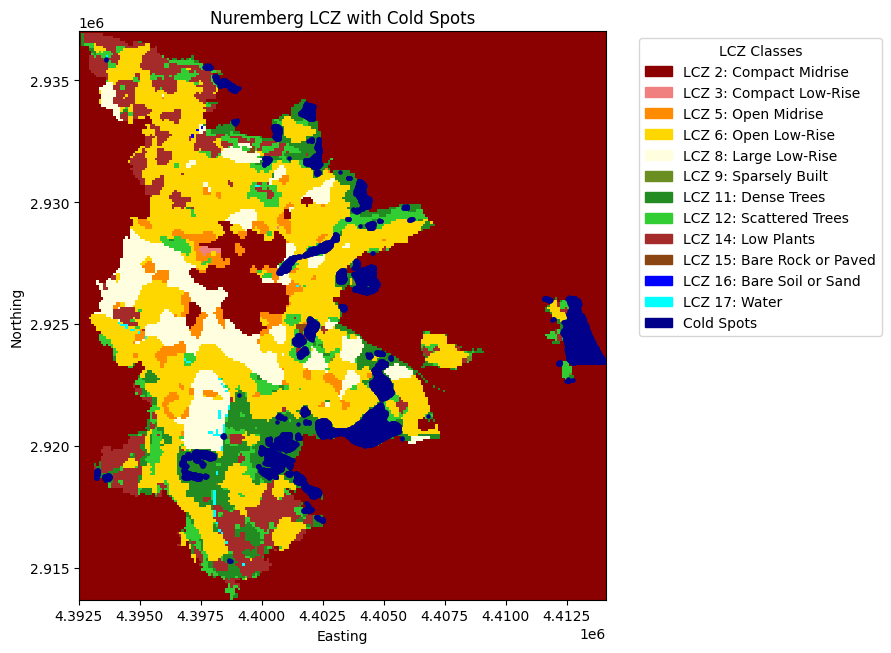

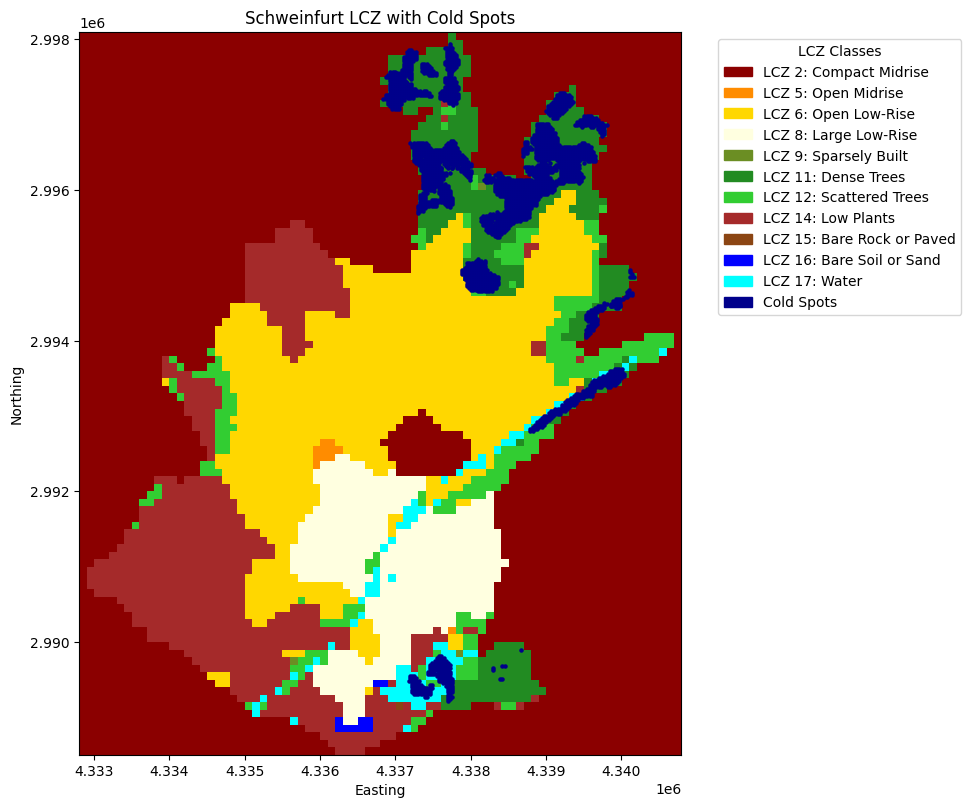

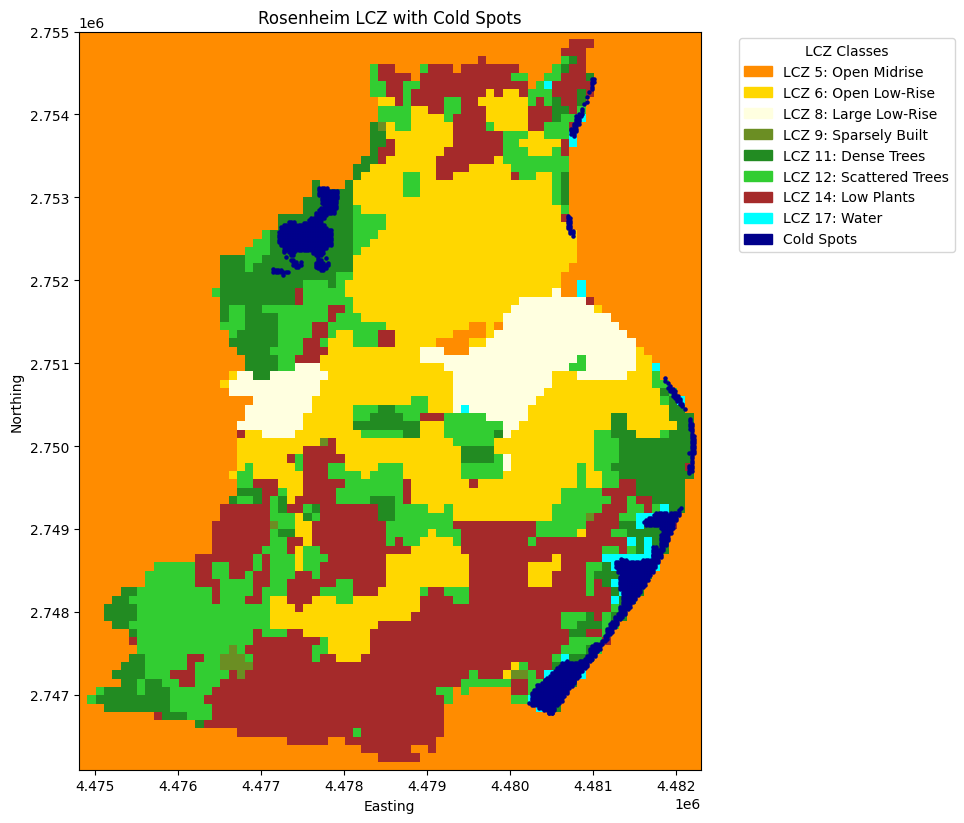

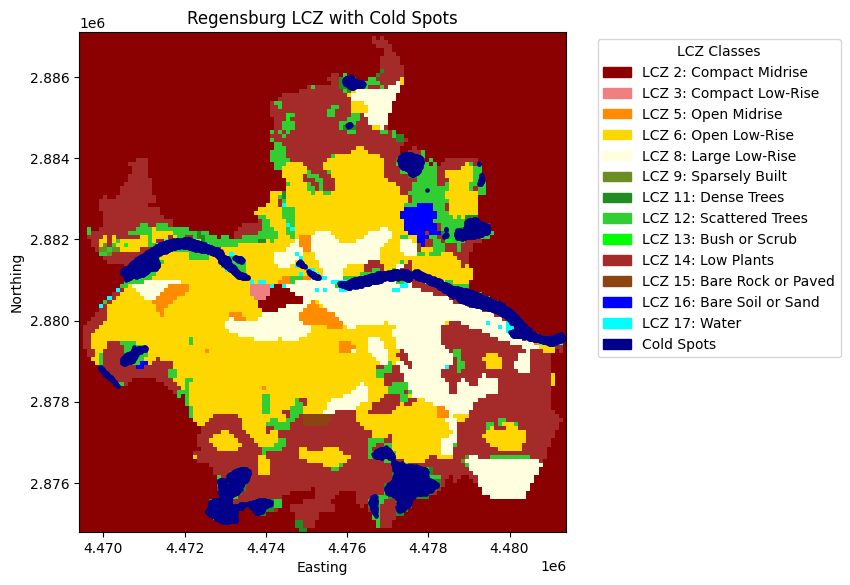

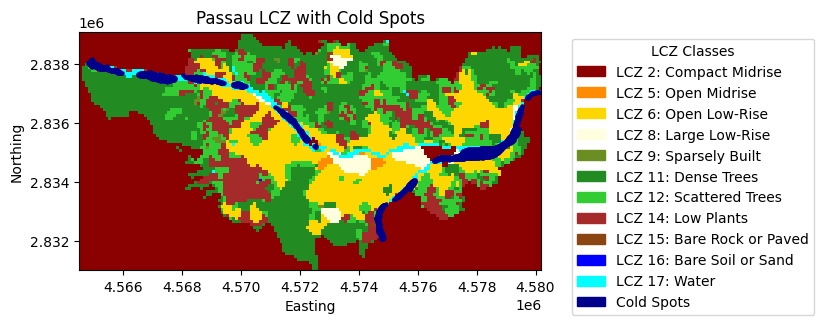

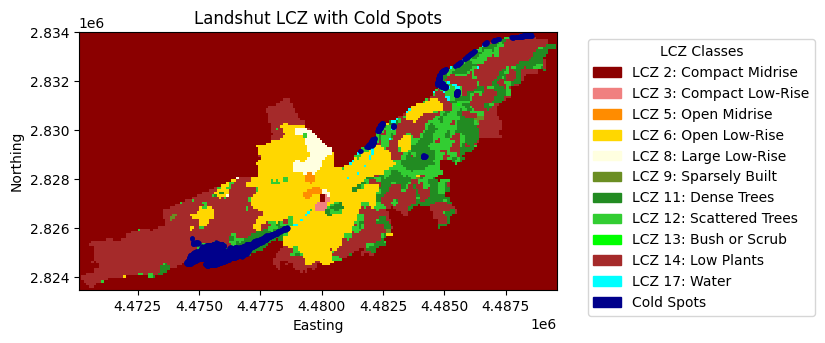

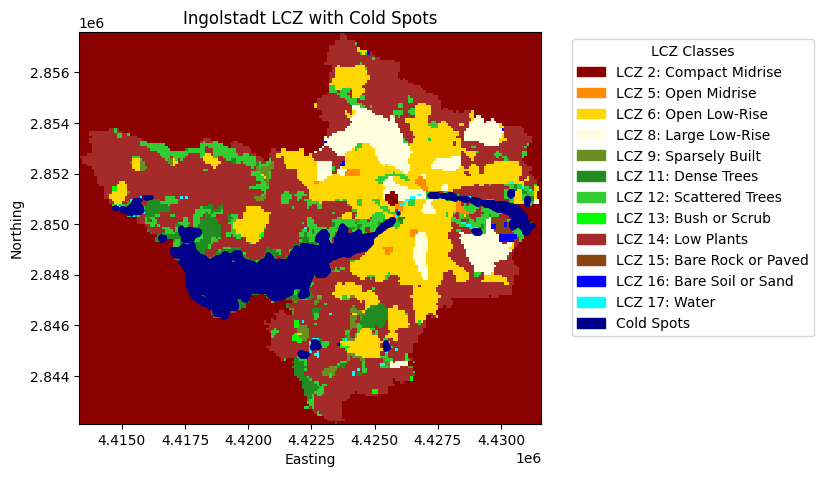

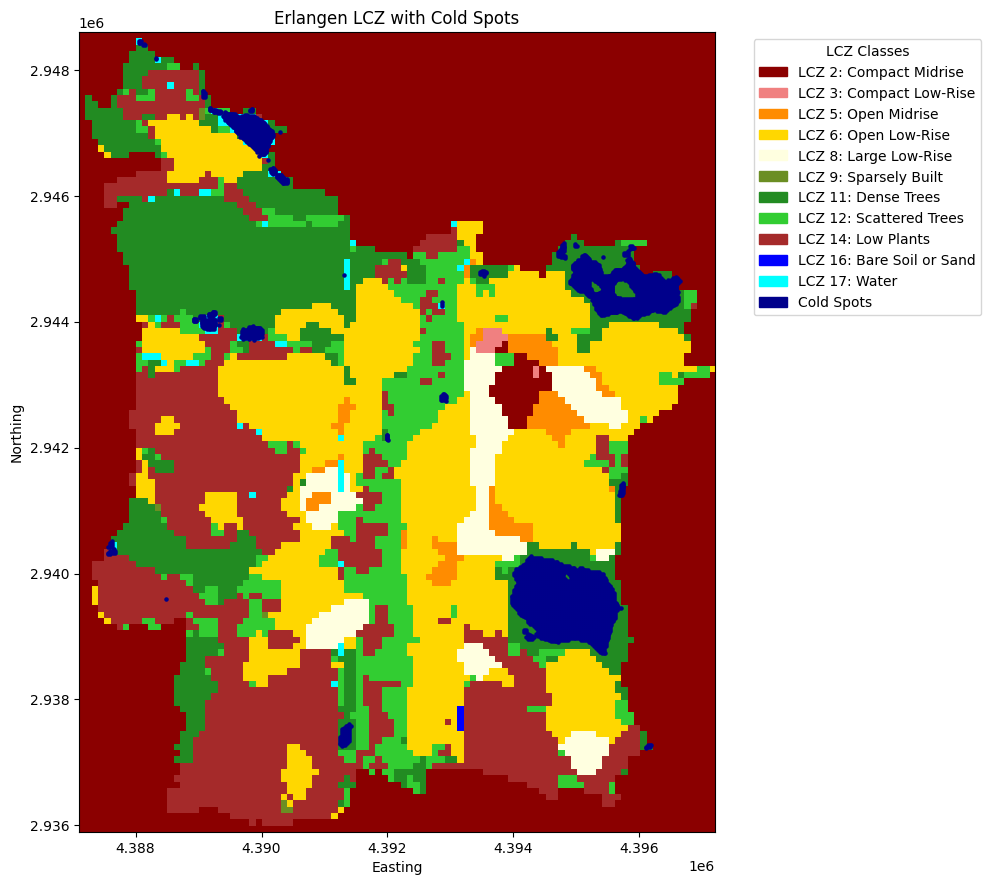

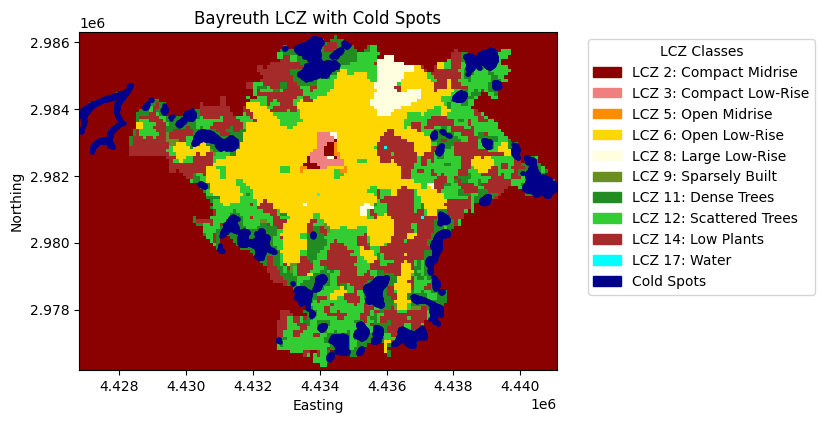

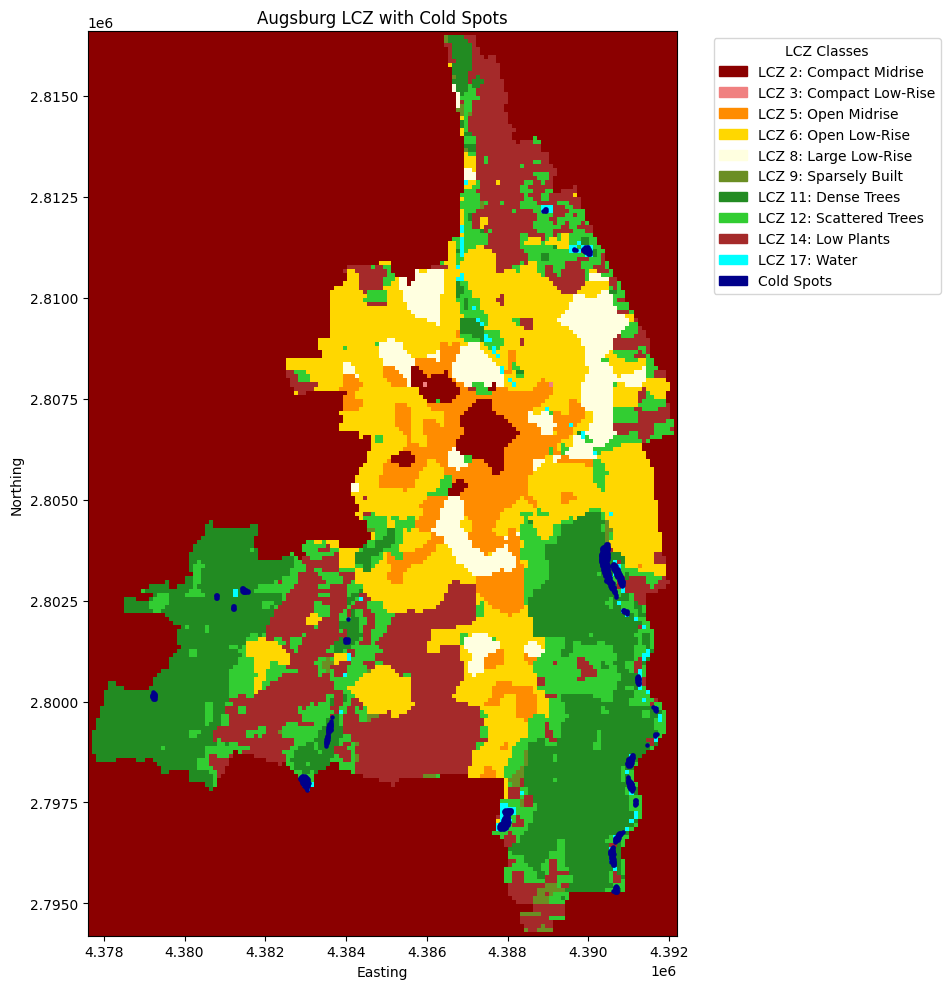

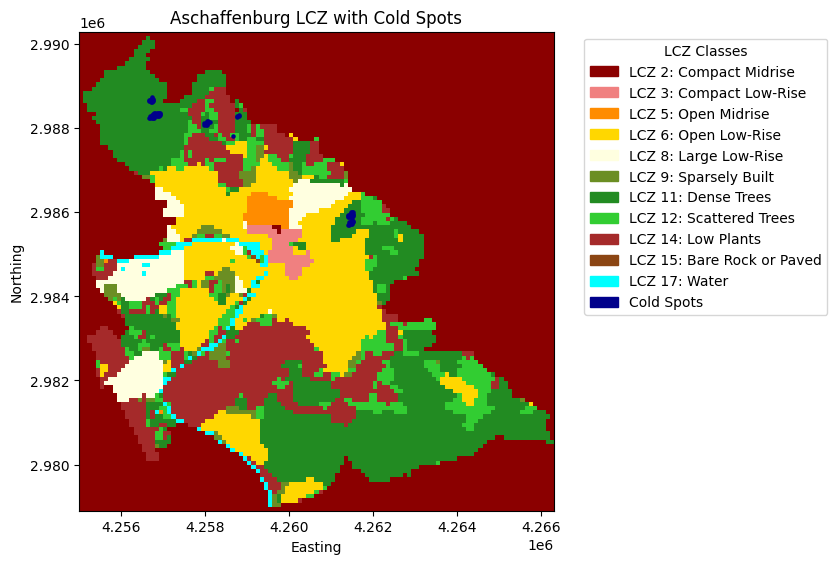

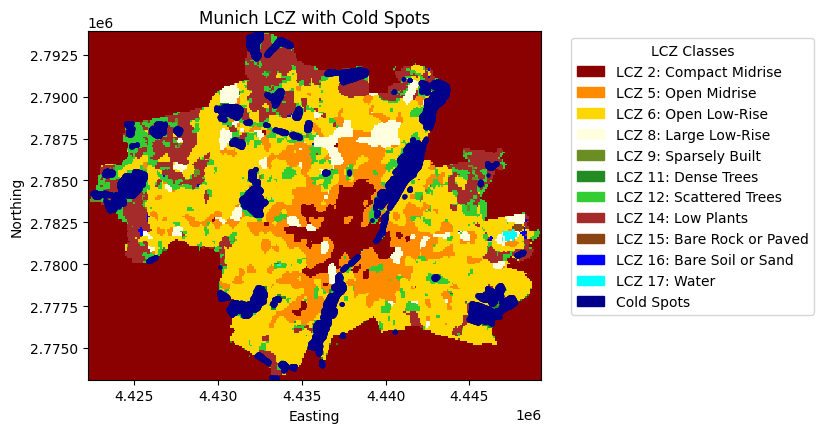

In [17]:
import matplotlib.pyplot as plt
from rasterio.plot import show
import matplotlib.patches as mpatches

# Define LCZ descriptions and colors for the legend
lcz_colors = {
    1: 'red', 2: 'darkred', 3: 'lightcoral', 4: 'orange', 5: 'darkorange',
    6: 'gold', 7: 'yellow', 8: 'lightyellow', 9: 'olivedrab', 10: 'darkgreen',
    11: 'forestgreen', 12: 'limegreen', 13: 'lime', 14: 'brown', 15: 'saddlebrown',
    16: 'blue', 17: 'cyan', # Example colors, adjust as needed
    0: 'grey' # Color for No Data
}

# Print the results with LCZ descriptions
lcz_descriptions = {
    1: "Compact High-Rise", 2: "Compact Midrise", 3: "Compact Low-Rise",
    4: "Open High-Rise", 5: "Open Midrise", 6: "Open Low-Rise",
    7: "Lightweight Low-Rise", 8: "Large Low-Rise", 9: "Sparsely Built",
    10: "Heavy Industry", 11: "Dense Trees", 12: "Scattered Trees",
    13: "Bush or Scrub", 14: "Low Plants", 15: "Bare Rock or Paved",
    16: "Bare Soil or Sand", 17: "Water",
    0: "No Data/Outside LCZ mask" }

# Filter for cities that have both clipped rasters and cold spot data with LCZ values
cities_to_visualize = {
    city: cold_spots_with_lcz[city]
    for city in cold_spots_with_lcz
    if city in clipped_rasters and clipped_rasters[city] is not None
}

if not cities_to_visualize:
    print("No cities with both clipped raster and cold spot data found for visualization.")
else:
    # Iterate through the cities and create a separate plot for each
    for city, cold_spots_gdf in cities_to_visualize.items():
        # Create a new figure for each city
        fig, ax = plt.subplots(1, 1, figsize=(10, 10)) # Adjust figsize as needed for larger plots

        # Get the corresponding clipped raster info
        clipped_raster_info = clipped_rasters[city]
        clipped_data = clipped_raster_info["data"]
        clipped_transform = clipped_raster_info["transform"]

        # Assuming the clipped data is a single band (shape: (1, height, width))
        clipped_band = clipped_data[0]

        # Plot the clipped LCZ raster
        # Use a colormap and specify bounds to map colors to discrete LCZ values
        # We need to create a custom colormap or use a listed colormap for discrete values
        # Let's create a colormap and normalization for the specific LCZ values present in the data

        # Get unique LCZ values in the clipped raster band for this city
        unique_lcz_values = np.unique(clipped_band)
        # Filter out the No Data value if present and not relevant for colormap
        unique_lcz_values = unique_lcz_values[unique_lcz_values != 0] # Assuming 0 is No Data

        # Create a colormap and normalization for the unique LCZ values
        colors = [lcz_colors.get(val, 'gray') for val in unique_lcz_values]
        cmap = plt.matplotlib.colors.ListedColormap(colors)
        # Define bounds for the colormap - ensure each unique value falls in its own bin
        bounds = np.array(unique_lcz_values) - 0.5
        bounds = np.append(bounds, bounds[-1] + 1)
        norm = plt.matplotlib.colors.BoundaryNorm(bounds, cmap.N)


        # Plot the clipped raster with the custom colormap
        image = show(clipped_band, ax=ax, transform=clipped_transform, cmap=cmap, norm=norm, interpolation='nearest')

        # Overlay the cold spot points
        # Filter out cold spots with None LCZ values (outside raster extent) if not already done
        valid_cold_spots = cold_spots_gdf.dropna(subset=['lcz_value'])
        if not valid_cold_spots.empty:
             # Change marker color to darkblue
             valid_cold_spots.plot(ax=ax, marker='o', color='darkblue', markersize=5, label='Cold Spots')


        # Set title
        ax.set_title(f'{city} LCZ with Cold Spots')
        ax.set_xlabel('Easting') # Assuming projected CRS units (meters)
        ax.set_ylabel('Northing') # Assuming projected CRS units (meters)


        # Create a legend for the LCZ colors
        legend_patches = []
        # Sort unique LCZ values for consistent legend order
        sorted_unique_lcz_values = sorted(unique_lcz_values)

        for lcz_val in sorted_unique_lcz_values:
            color = lcz_colors.get(lcz_val, 'grey')
            description = lcz_descriptions.get(lcz_val, 'Unknown LCZ')
            patch = mpatches.Patch(color=color, label=f'LCZ {int(lcz_val)}: {description}')
            legend_patches.append(patch)

        # Add a patch for the Cold Spots layer with the new color
        if not valid_cold_spots.empty:
            cold_spot_patch = mpatches.Patch(color='darkblue', label='Cold Spots')
            legend_patches.append(cold_spot_patch)


        # Add the legend to the plot
        # Position the legend outside the plot if possible
        ax.legend(handles=legend_patches, title="LCZ Classes", bbox_to_anchor=(1.05, 1), loc='upper left')


        plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to prevent overlapping and make space for legend
        plt.show()

## Prozentuale Verteilung der Cold Spots pro LCZ (alle Städte (außer Wü, Fü und Kempt))

### Subtask:
Berechnen Sie den prozentualen Anteil der Cold Spots für jede LCZ über alle Städte hinweg.

In [18]:
import pandas as pd

# Aggregate the LCZ cold spot counts across all cities
# Combine the series from the dictionary into a single Series, summing up counts for each LCZ
all_cities_lcz_counts = pd.concat(lcz_cold_spot_counts.values()).groupby(level=0).sum()

# Calculate the total number of cold spots across all cities
total_cold_spots = all_cities_lcz_counts.sum()

# Calculate the percentage of cold spots for each LCZ
lcz_percentages = (all_cities_lcz_counts / total_cold_spots) * 100

# Sort the percentages in descending order for better readability
lcz_percentages_sorted = lcz_percentages.sort_values(ascending=False)

print("Prozentuale Verteilung der Cold Spots pro LCZ (alle Städte zusammen):")

# Print the results with LCZ descriptions
lcz_descriptions = {
    1: "Compact High-Rise", 2: "Compact Midrise", 3: "Compact Low-Rise",
    4: "Open High-Rise", 5: "Open Midrise", 6: "Open Low-Rise",
    7: "Lightweight Low-Rise", 8: "Large Low-Rise", 9: "Sparsely Built",
    10: "Heavy Industry", 11: "Dense Trees", 12: "Scattered Trees",
    13: "Bush or Scrub", 14: "Low Plants", 15: "Bare Rock or Paved",
    16: "Bare Soil or Sand", 17: "Water",
    0: "No Data/Outside LCZ mask"
}

for lcz_value, percentage in lcz_percentages_sorted.items():
    # Ensure LCZ value is an integer for lookup
    lcz_value_int = int(lcz_value)
    description = lcz_descriptions.get(lcz_value_int, "Unknown LCZ")
    print(f"LCZ {lcz_value_int} ({description}): {percentage:.2f}%")

Prozentuale Verteilung der Cold Spots pro LCZ (alle Städte zusammen):
LCZ 11 (Dense Trees): 68.89%
LCZ 17 (Water): 12.77%
LCZ 12 (Scattered Trees): 11.66%
LCZ 14 (Low Plants): 2.38%
LCZ 0 (No Data/Outside LCZ mask): 2.09%
LCZ 6 (Open Low-Rise): 1.63%
LCZ 5 (Open Midrise): 0.21%
LCZ 8 (Large Low-Rise): 0.18%
LCZ 15 (Bare Rock or Paved): 0.08%
LCZ 9 (Sparsely Built): 0.05%
LCZ 2 (Compact Midrise): 0.03%
LCZ 13 (Bush or Scrub): 0.02%


Würzburg, Fürth und Kempten müssen noch gefixt/verarbeitet werden